# Fine-tuning Nucleotide Transformer for chromatin accessibility prediction

Using the 2.5m param model always goes OOM instantly when training, even on an 80GB H100 with batch size 1, so I'm using the smaller 500m param model.

I moved the actual fine-tuning to scripts since this takes a very long time - this notebook will show you the training results. If you want to train within a notebook, I recommend looking at `finetune_hyenadna.ipynb`.

## Load packages

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## First round training

See `finetune_nuctrans.py` for the finetuning code.

### First-round metrics

In [4]:
metrics = pd.concat([pd.read_csv('nuctrans/lightning_logs/version_0/metrics.csv'), pd.read_csv('nuctrans/lightning_logs/version_3/metrics.csv')])
metrics

,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
0,0,49,-0.779316,1.279262,0.771192,NaN,NaN,NaN
1,0,99,0.092591,134.776901,0.709440,NaN,NaN,NaN
2,0,149,-0.142216,30.877531,0.478741,NaN,NaN,NaN
3,0,199,0.158846,28.425480,0.116815,NaN,NaN,NaN
4,0,249,-0.184510,3.801391,0.382480,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
25571,8,1939799,0.156951,24.900537,-0.156848,NaN,NaN,NaN
25572,8,1939849,-0.403138,14.232710,0.653975,NaN,NaN,NaN
25573,8,1939899,-0.897647,36.369301,0.831528,NaN,NaN,NaN
25574,8,1939949,-0.028983,24.463297,-0.239555,NaN,NaN,NaN


In [5]:
metrics_val = metrics[metrics['val_loss'].notna()]
metrics_val

,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
4409,0,220496,NaN,NaN,NaN,-0.215397,96.205170,0.320226
8820,1,440993,NaN,NaN,NaN,-0.316734,74.903656,0.354175
13231,2,661490,NaN,NaN,NaN,-0.309499,66.878426,0.366521
4410,3,881987,NaN,NaN,NaN,-0.336432,61.157143,0.375914
8821,4,1102484,NaN,NaN,NaN,-0.339833,58.914299,0.381449
13232,5,1322981,NaN,NaN,NaN,-0.351375,58.400173,0.383219
17643,6,1543478,NaN,NaN,NaN,-0.349135,58.883568,0.382749
22054,7,1763975,NaN,NaN,NaN,-0.349521,58.596565,0.380837


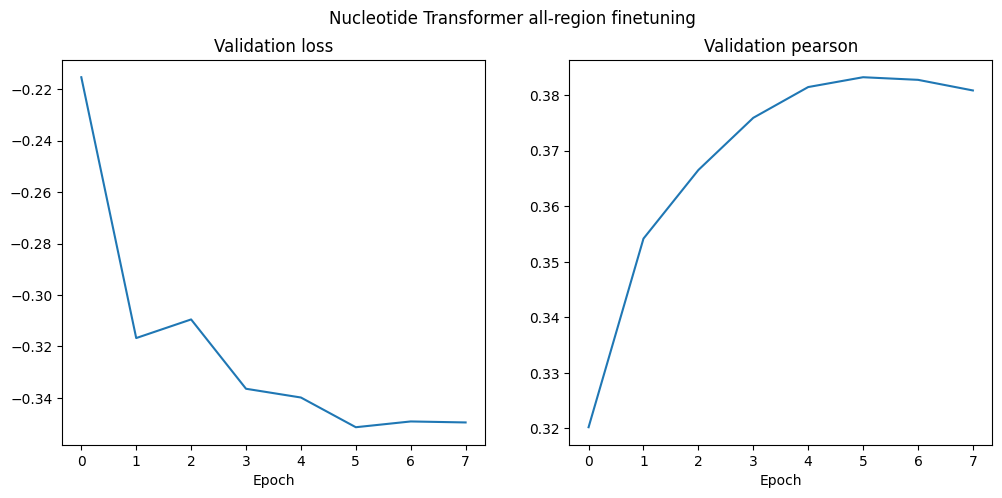

In [6]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5))
axs[0].plot(metrics_val['epoch'], metrics_val['val_loss'], label = 'Validation loss')
axs[0].set_title('Validation loss')
axs[1].plot(metrics_val['epoch'], metrics_val['val_pearson'], label = 'Validation pearson')
axs[1].set_title('Validation pearson')

axs[0].set_xlabel('Epoch')
axs[1].set_xlabel('Epoch')
fig.suptitle('Nucleotide Transformer all-region finetuning')
plt.show()

## Second-round training

See `finetune_nuctrans_further.py` for the finetuning code.

### Second-round metrics

In [2]:
metrics = pd.read_csv('nuctrans/lightning_logs/version_6/metrics.csv')
metrics

,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
0,0,49,0.200032,175.892792,0.699825,NaN,NaN,NaN
1,0,99,-0.476112,5.993709,0.486035,NaN,NaN,NaN
2,0,149,-0.421356,8.962100,0.659707,NaN,NaN,NaN
3,0,199,-0.302991,6.805669,0.222505,NaN,NaN,NaN
4,0,249,-0.068886,18.539564,0.275705,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
4104,5,204999,-0.304186,14.843313,0.276629,NaN,NaN,NaN
4105,5,205049,-0.280250,38.698925,0.571651,NaN,NaN,NaN
4106,5,205099,0.161023,114.930931,0.087508,NaN,NaN,NaN
4107,5,205149,0.305669,79.076637,-0.020595,NaN,NaN,NaN


In [3]:
metrics_val = metrics[metrics['val_loss'].notna()]
metrics_val

,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
733,0,36662,NaN,NaN,NaN,-0.130193,30.026636,0.346440
1467,1,73325,NaN,NaN,NaN,-0.135379,29.924665,0.346917
2201,2,109988,NaN,NaN,NaN,-0.132983,29.950266,0.346985
2936,3,146651,NaN,NaN,NaN,-0.135861,29.905069,0.346456
3670,4,183314,NaN,NaN,NaN,-0.137622,29.872057,0.347042


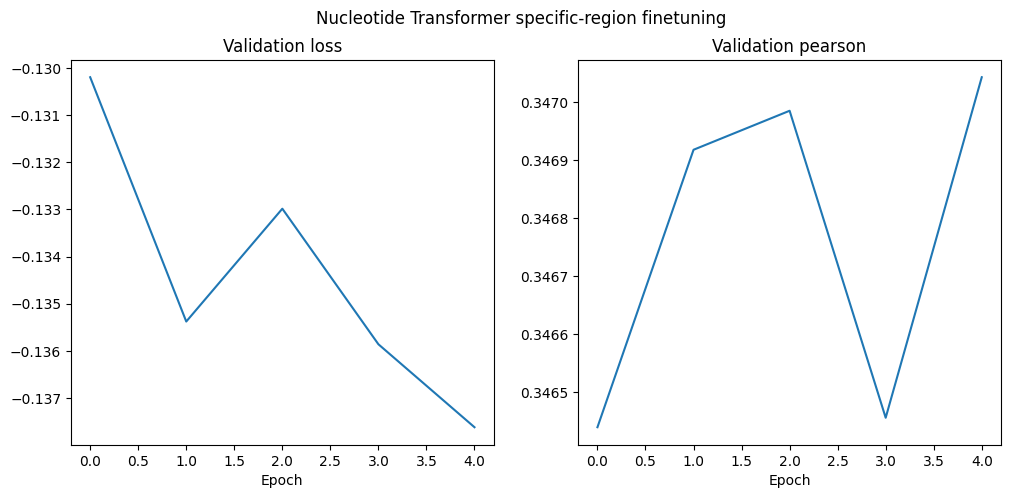

In [4]:
# version_6, the 'correct' second-round finetuning with 1e-5 and correct region size
fig, axs = plt.subplots(1, 2, figsize = (12, 5))
axs[0].plot(metrics_val['epoch'], metrics_val['val_loss'], label = 'Validation loss')
axs[0].set_title('Validation loss')
axs[1].plot(metrics_val['epoch'], metrics_val['val_pearson'], label = 'Validation pearson')
axs[1].set_title('Validation pearson')

axs[0].set_xlabel('Epoch')
axs[1].set_xlabel('Epoch')
fig.suptitle('Nucleotide Transformer specific-region finetuning')
plt.show()